In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize
from models import CRW
from tqdm import tqdm

In [2]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
figsize = (12,9)

In [3]:
# generate 1000 CRW polymers of length 10-1000, and record their statistics
low=10
high=1000

num_crw = 500

rng = np.random.default_rng()
crw_list = [CRW(int(10**rng.uniform(np.log10(low),np.log10(high)))) for i in tqdm(range(num_crw))]

100%|██████████| 500/500 [00:17<00:00, 28.48it/s]


In [4]:
print(crw_list)

[<models.CRW object at 0x7f8e76c8bb60>, <models.CRW object at 0x7f8e76cc9bd0>, <models.CRW object at 0x7f8e76cc9d10>, <models.CRW object at 0x7f8e76d05480>, <models.CRW object at 0x7f8e76d055b0>, <models.CRW object at 0x7f8e76cae8d0>, <models.CRW object at 0x7f8e76ac58c0>, <models.CRW object at 0x7f8e76ac5150>, <models.CRW object at 0x7f8e76cb3150>, <models.CRW object at 0x7f8e76cb3550>, <models.CRW object at 0x7f8e76ac0c80>, <models.CRW object at 0x7f8e76ac1130>, <models.CRW object at 0x7f8e76cd6c10>, <models.CRW object at 0x7f8e76cd6970>, <models.CRW object at 0x7f8e76ab8940>, <models.CRW object at 0x7f8e76dafad0>, <models.CRW object at 0x7f8e76dafdd0>, <models.CRW object at 0x7f8e76adea40>, <models.CRW object at 0x7f8e76ade990>, <models.CRW object at 0x7f8e76cfd950>, <models.CRW object at 0x7f8e76cfdbd0>, <models.CRW object at 0x7f8e76cf8c20>, <models.CRW object at 0x7f8e76af4050>, <models.CRW object at 0x7f8e76ce3cd0>, <models.CRW object at 0x7f8e76ccd6a0>, <models.CRW object at 0x

In [5]:
crw_list[1].show()

CRW of length 26:
	Sigma: 1
	U_bb: 1
	e_rep: 1
Stats:
	Radius of Gyration: 2.645958662033081
	Total Potential Energy: 5.684341886080802e-14
Residues:
(0.0, 0.0, 0.0)
(-0.601489245891571, 0.7317818403244019, -0.32047784328460693)
(-0.11126437783241272, 1.5782042741775513, -0.11251472681760788)
(0.7669983506202698, 1.4741249084472656, 0.3541994094848633)
(1.1493091583251953, 0.6361566781997681, -0.03522028774023056)
(2.0705978870391846, 0.3144737780094147, -0.2537320852279663)
(2.19521164894104, 1.3033339977264404, -0.3351379632949829)
(2.007105588912964, 2.273383617401123, -0.4888257682323456)
(1.5148067474365234, 1.7203969955444336, -1.1610219478607178)
(0.6274223327636719, 1.38824462890625, -1.4807463884353638)


In [6]:
lengths = [crw.n for crw in tqdm(crw_list)]
R_gs = [float(crw.compute_rg()) for crw in tqdm(crw_list)]

print(lengths)
print(R_gs)

100%|██████████| 500/500 [00:00<00:00, 12215.68it/s]

[267, 26, 957, 184, 20, 107, 964, 19, 273, 932, 68, 241, 487, 25, 33, 34, 48, 12, 61, 111, 41, 833, 159, 13, 464, 130, 177, 156, 732, 470, 10, 918, 35, 499, 49, 260, 436, 111, 20, 86, 40, 806, 370, 23, 67, 163, 110, 463, 63, 21, 13, 18, 14, 40, 223, 20, 379, 537, 81, 888, 10, 410, 308, 69, 71, 45, 360, 608, 625, 122, 149, 73, 131, 625, 10, 23, 866, 10, 209, 175, 601, 20, 55, 21, 15, 275, 20, 13, 18, 208, 598, 45, 34, 770, 46, 652, 40, 17, 30, 267, 99, 133, 691, 550, 22, 361, 314, 856, 273, 182, 80, 51, 71, 65, 46, 180, 264, 496, 664, 938, 25, 26, 302, 658, 20, 44, 165, 95, 50, 378, 241, 58, 115, 123, 55, 597, 94, 100, 394, 602, 52, 151, 223, 920, 31, 41, 275, 18, 174, 28, 161, 10, 18, 37, 24, 267, 114, 58, 85, 137, 514, 100, 27, 24, 17, 20, 57, 403, 19, 358, 11, 16, 80, 76, 276, 335, 24, 477, 227, 189, 186, 468, 915, 741, 26, 352, 831, 56, 109, 29, 887, 416, 716, 311, 665, 81, 112, 84, 60, 30, 11, 185, 260, 400, 29, 157, 30, 17, 119, 74, 15, 158, 534, 15, 16, 401, 921, 87, 350, 567, 94

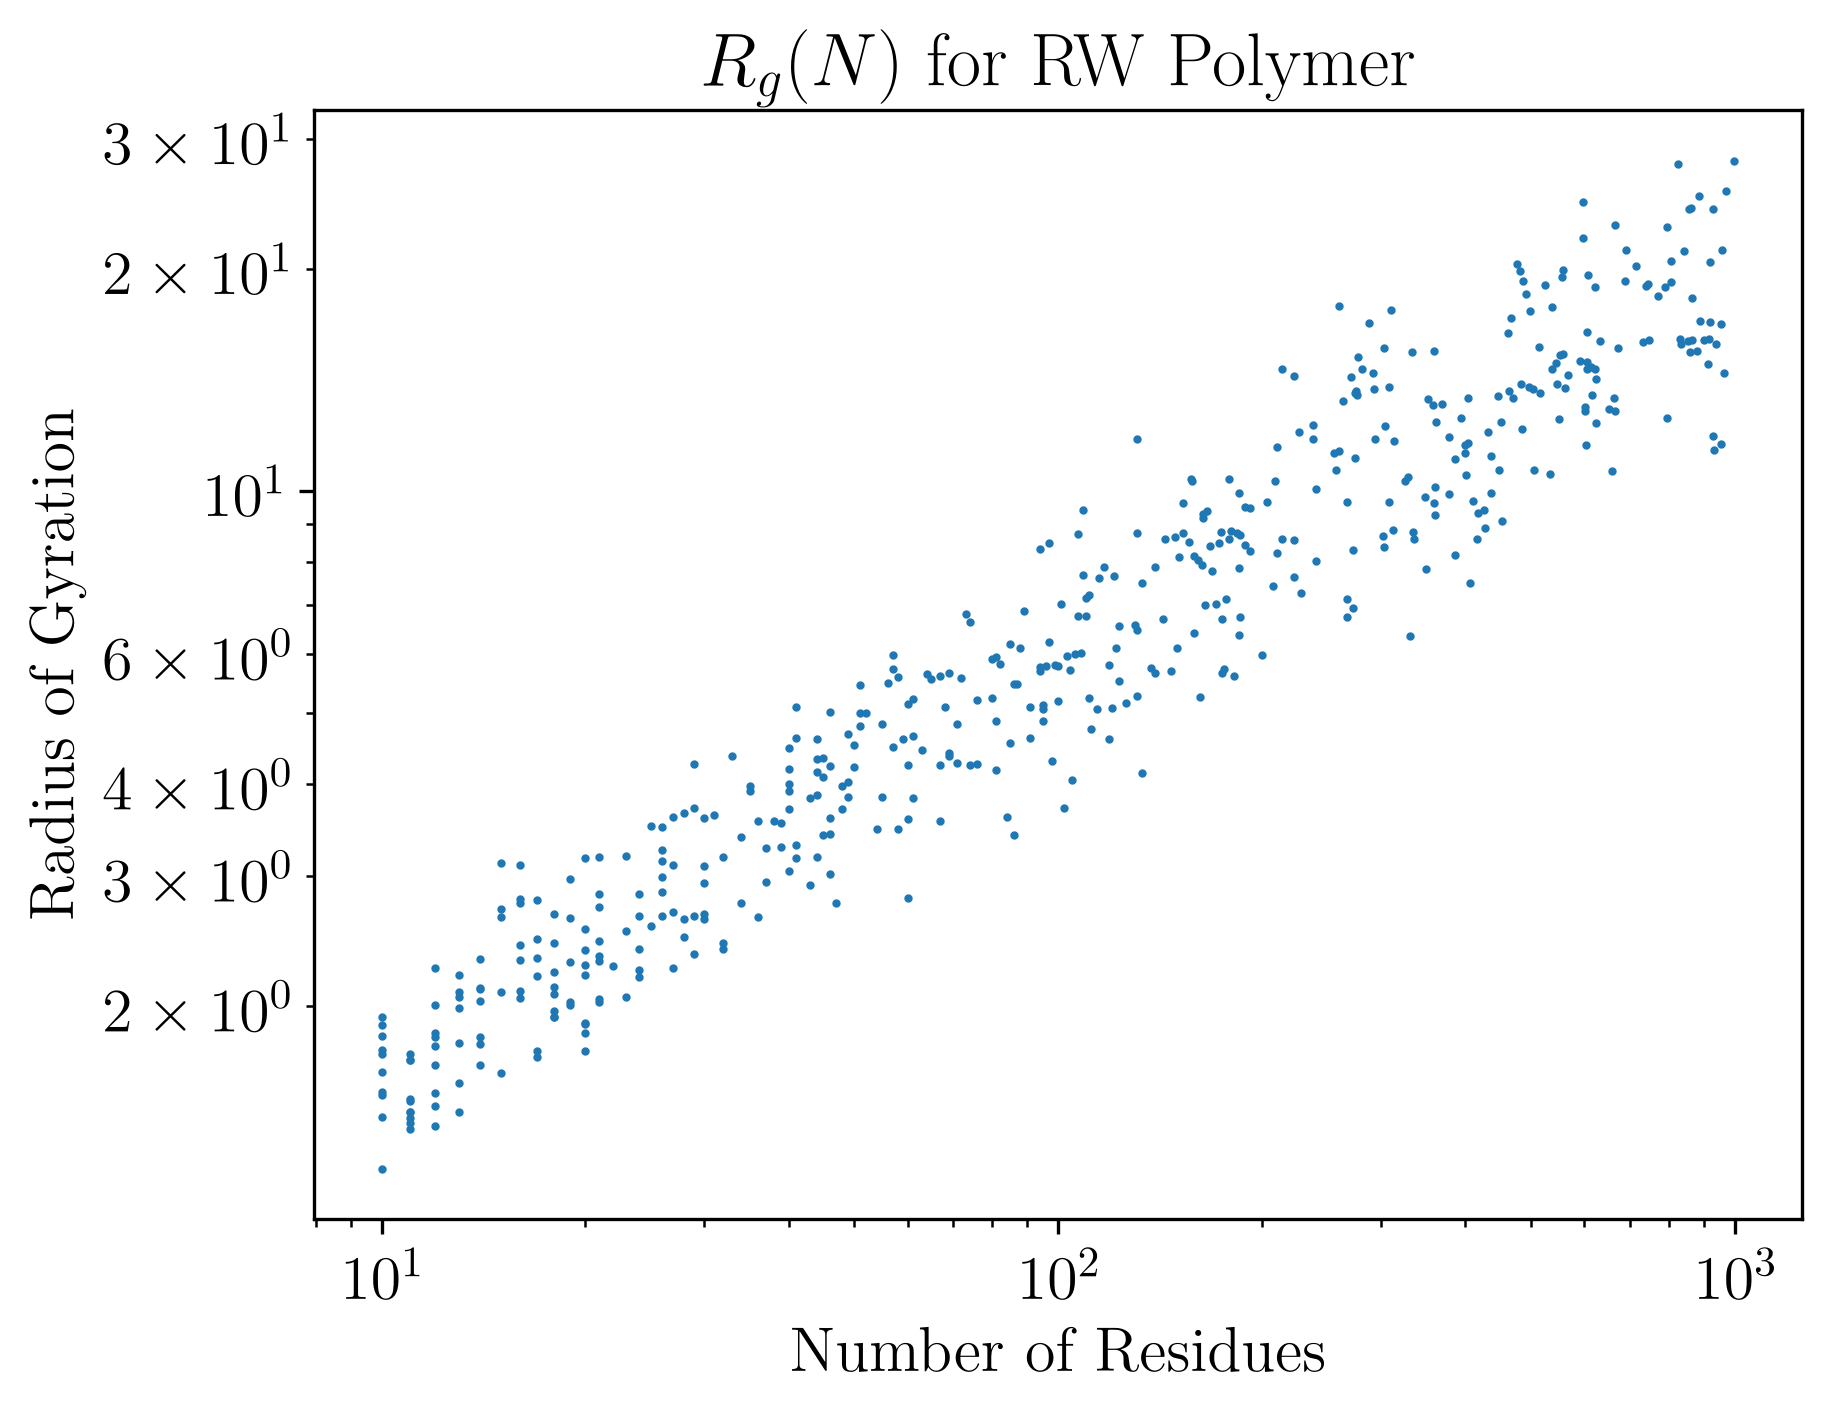

In [7]:
plt.figure()
plt.scatter(lengths, R_gs, s=1, label="Radius of Gyration")
plt.ylabel("Radius of Gyration")
plt.xlabel("Number of Residues")
plt.xscale("log")
plt.yscale("log")
plt.title(r"$R_g(N)$ for RW Polymer")
plt.savefig("RgVsN.png")

100%|██████████| 500/500 [11:42<00:00,  1.41s/it]
/tmp/ipykernel_39082/2695379395.py:26: RuntimeWarning: Mean of empty slice
  mean_Rg_n = np.nanmean(Rg_ns, axis=0)
/home/patrick/Projects/protein-folding/programs/Constrained-Polymer-Collapse/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


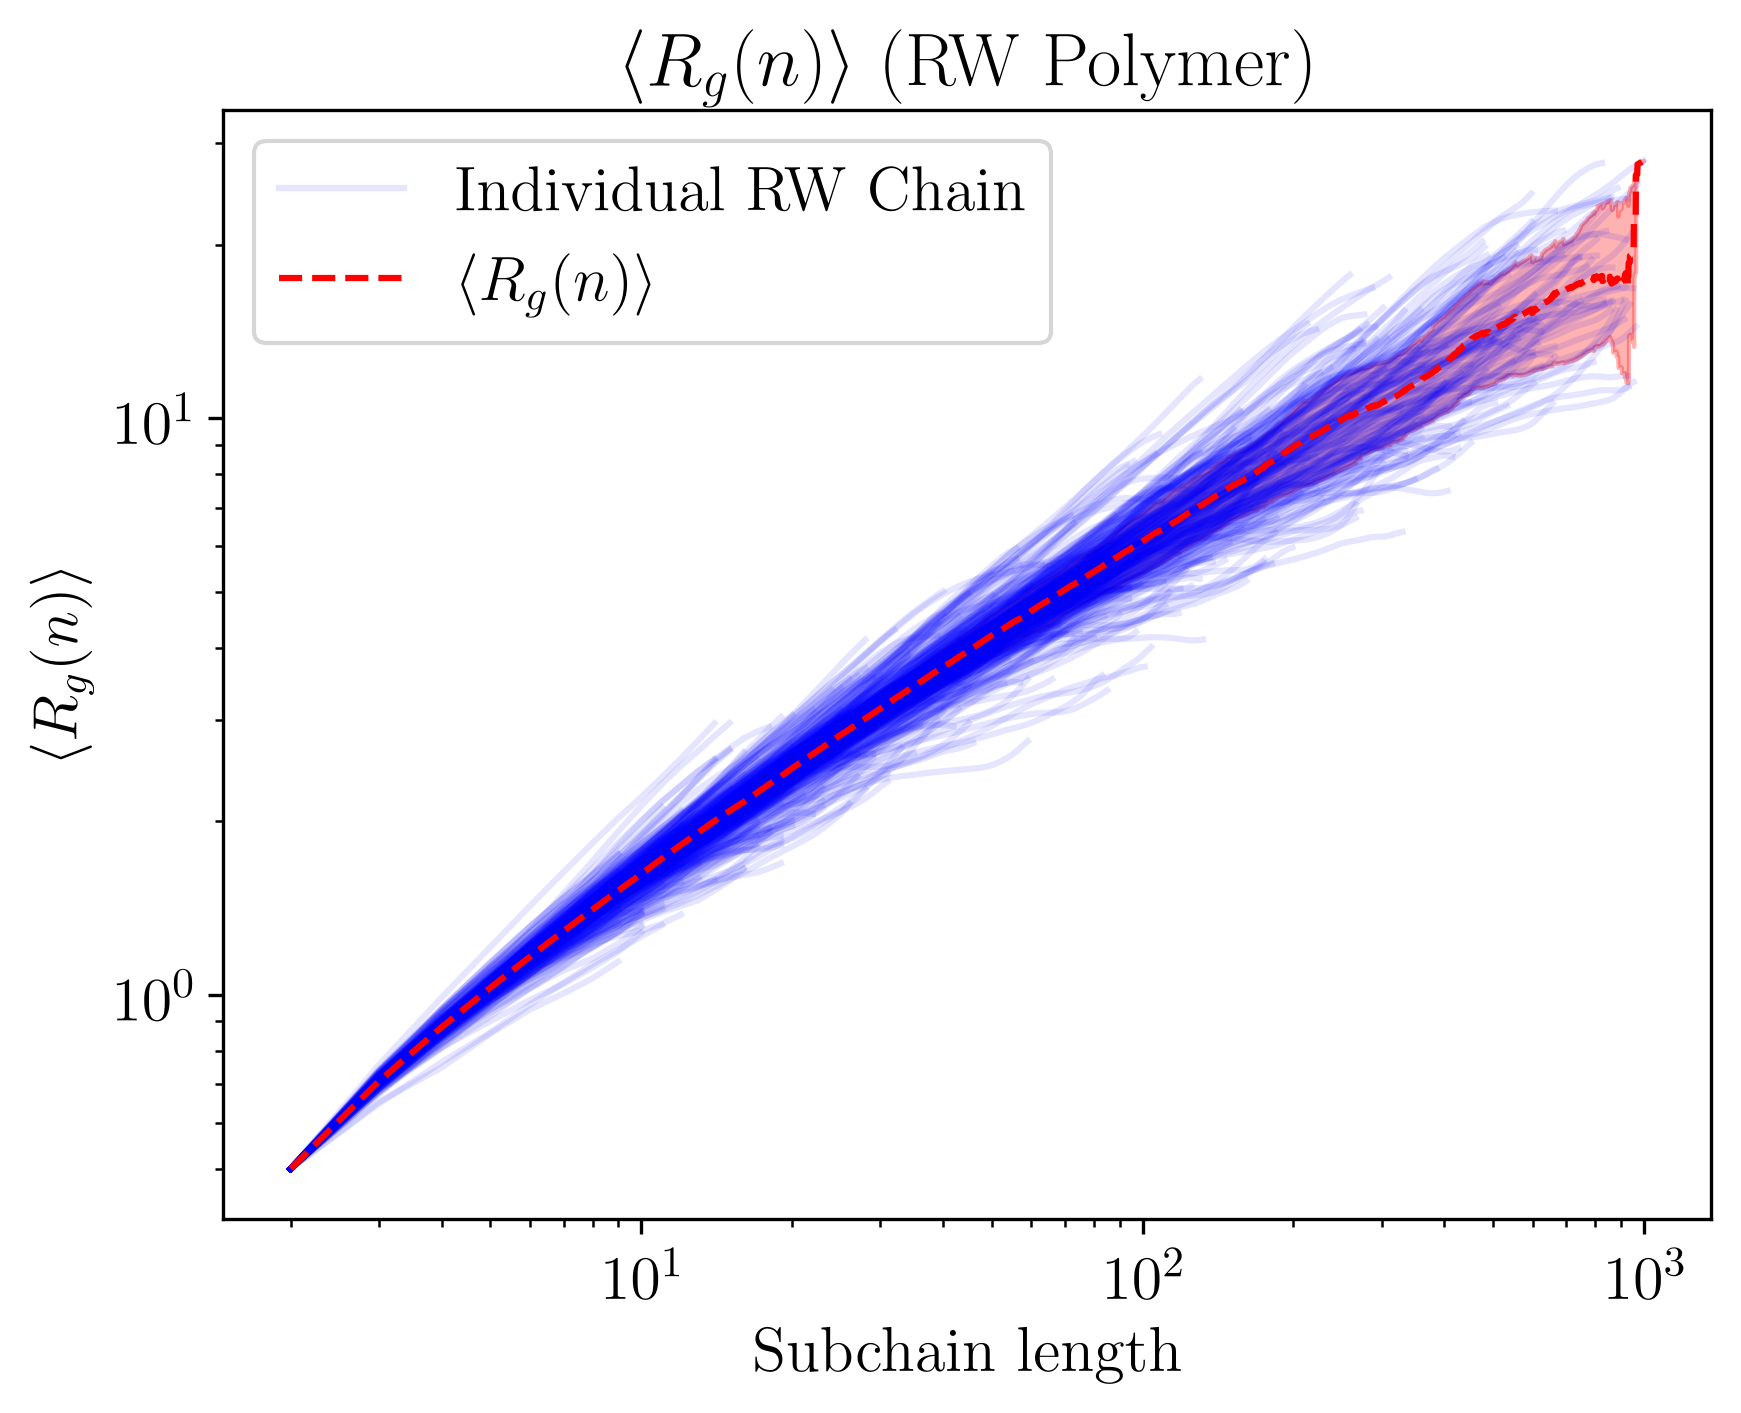

In [8]:
n_max = max(crw.n for crw in crw_list)

ns = np.arange(2, n_max+1)
Rg_ns = np.full((num_crw, len(ns)), np.nan)

plt.figure()
plt.title(r"$\langle R_g(n)\rangle$ (RW Polymer)")
plt.xlabel("Subchain length")
plt.ylabel(r"$\langle R_g(n) \rangle$")
plt.xscale("log")
plt.yscale("log")
for crw_idx, crw in enumerate(tqdm(crw_list)):
    
    valid_ns = ns[ns < crw.n]
     
    for n_idx, n in enumerate(valid_ns):
        Rg_ns[crw_idx, n_idx]=crw.compute_rg_n(n)
    plt.plot(
             valid_ns, 
             Rg_ns[crw_idx, :len(valid_ns)], 
             c="b", 
             alpha=.1, 
             label="Individual RW Chain" if crw_idx == 0 else "_nolegend_"
        )

mean_Rg_n = np.nanmean(Rg_ns, axis=0)
Rg_lo, Rg_hi = np.nanpercentile(Rg_ns, [16, 84], axis=0)

plt.plot(ns, mean_Rg_n, c="r", linestyle="--",label=r"$\langle R_g(n) \rangle$")
plt.fill_between(ns, Rg_lo, Rg_hi, color="r", alpha=.3)
plt.legend()
plt.savefig("Rg_n.png")
plt.show()

In [9]:
# Now when the polymers begin to fold what happens?
# First examine different central forces, and what they do to to final R_g(N) and the <R_g(n)> at different temperatures
# first output files to respective configs
for i, rw in enumerate(tqdm(crw_list)):
    rw.write_sim_config(f"../../input/rw_len_{rw.n}_no_{i}.txt")

100%|██████████| 500/500 [00:00<00:00, 502.76it/s]
